In [1]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UNet2DConditionModel, DDPMScheduler
from peft import PeftModel

# Ensure reproducibility by setting a fixed random seed
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Inference device: {device}")

Inference device: cuda


In [2]:
# 1. Define paths
model_id = "runwayml/stable-diffusion-v1-5"
controlnet_id = "lllyasviel/sd-controlnet-canny"
lora_path = "../demo/lora_weights" 

print("Loading ControlNet and base U-Net...")
controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch.float16).to(device)
base_unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16).to(device)

print("Injecting LoRA weights (PEFT)...")
unet = PeftModel.from_pretrained(base_unet, lora_path)
unet.eval()

# Build the Pipeline
scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    unet=unet,
    controlnet=controlnet,
    scheduler=scheduler,
    torch_dtype=torch.float16
).to(device)

pipe.safety_checker = None
print("Inference pipeline ready.")

Loading ControlNet and base U-Net...


c:\ProgramData\anaconda3\envs\diffusion_models\lib\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Injecting LoRA weights (PEFT)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\estiv\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\estiv\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Expected types for unet: (<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>,), got <class 'peft.peft_model.PeftModel'>.


Inference pipeline ready.


In [3]:
def get_text_embeddings(prompt, pipeline):
    """Extracts mathematical embeddings from text."""
    text_inputs = pipeline.tokenizer(
        prompt, padding="max_length", max_length=pipeline.tokenizer.model_max_length, 
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        return pipeline.text_encoder(text_inputs.input_ids.to(pipeline.device))[0]

def synthesize_defect(alpha, canny_image, target_size=320, seed=42):
    """
    Generates a part with a defect level controlled by alpha.
    alpha = 0.0 (OK Part) ---> alpha = 1.0 (Severe Defect)
    """
    prompt_ok = "photo of SKS_PART, top-down industrial inspection, circular machined component, flat grey ferrous material, flawless smooth surface, QC passed, neutral factory lighting, plain background"
    prompt_def = "photo of SKS_PART, top-down industrial inspection, circular machined component, flat grey ferrous material, severe porosity defect, surface blowholes and cavities, QC failed manufacturing reject, neutral factory lighting, plain background"
    negative_prompt = "relic, antique, museum, face, skull, mask, statue, bronze, gold, jewelry, ornate, complex shape, intricate, art, shiny, colorful, 3d render"

    # Extract embeddings
    embed_ok = get_text_embeddings(prompt_ok, pipe)
    embed_def = get_text_embeddings(prompt_def, pipe)
    embed_neg = get_text_embeddings(negative_prompt, pipe)

    # Latent Arithmetic: Linear interpolation
    interp_embeds = (1.0 - alpha) * embed_ok + alpha * embed_def

    # Freeze initial noise for background consistency
    generator = torch.Generator(device=device).manual_seed(seed)
    starting_latents = torch.randn(
        (1, pipe.unet.config.in_channels, target_size // 8, target_size // 8),
        generator=generator, device=device, dtype=torch.float16
    )

    # Generate image
    image = pipe(
        prompt_embeds=interp_embeds,
        negative_prompt_embeds=embed_neg,
        image=canny_image,
        width=target_size,
        height=target_size,
        latents=starting_latents,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]
    
    return image

Synthesizing defect progression...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

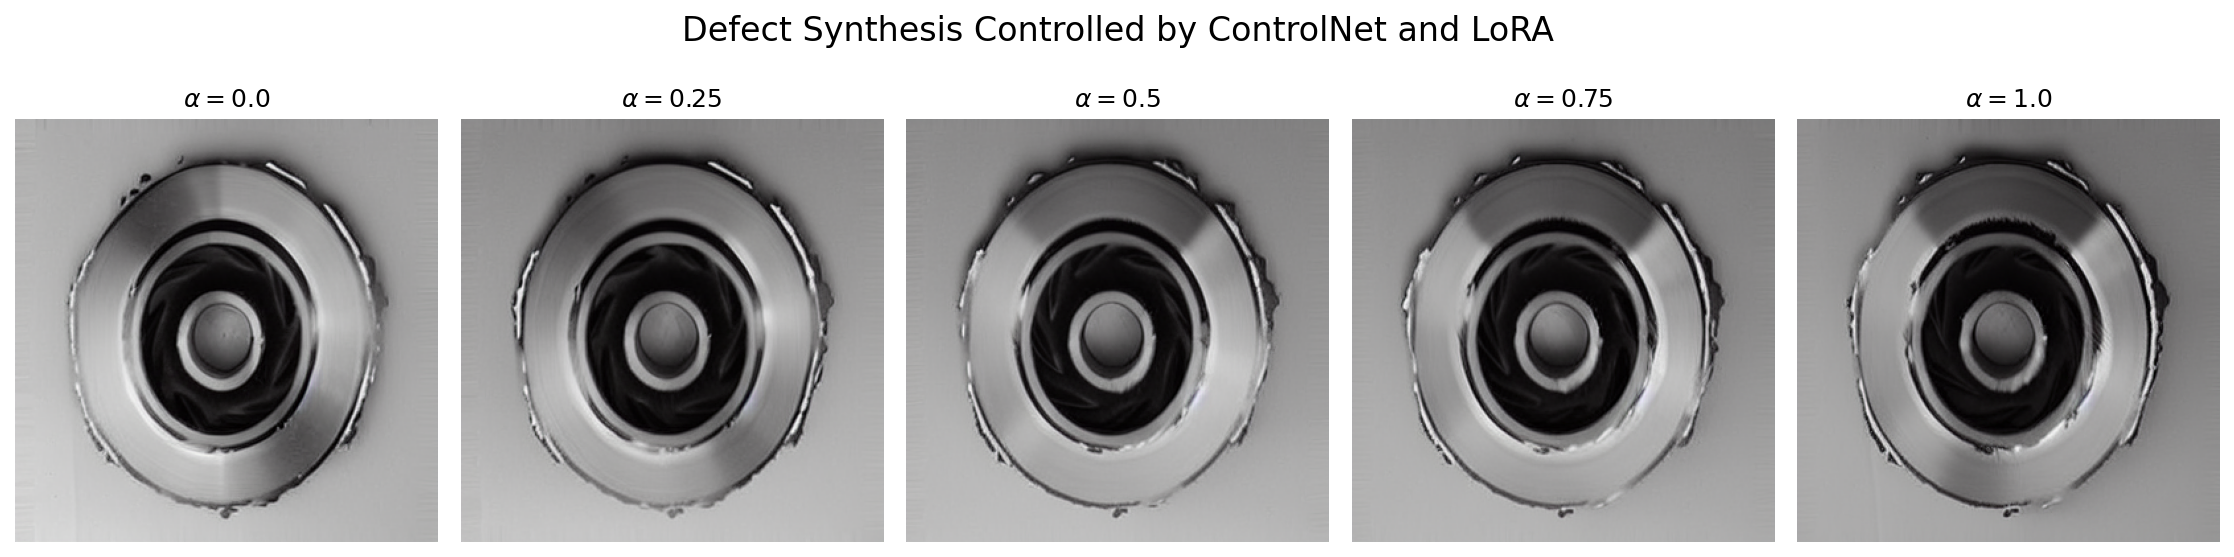

In [5]:
# Load template Canny image
canny_path = "../demo/assets/cast_def_0_0_canny.jpeg" # Make sure to place an image here
canny_image = Image.open(canny_path).convert("RGB").resize((320, 320), Image.Resampling.LANCZOS)

# Generate progression
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
results = []

print("Synthesizing defect progression...")
for a in alphas:
    img = synthesize_defect(alpha=a, canny_image=canny_image)
    results.append(img)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(15, 4), dpi=150)
for i, a in enumerate(alphas):
    axes[i].imshow(results[i])
    axes[i].axis('off')
    axes[i].set_title(r"$\alpha = {}$".format(a), fontsize=12)

plt.suptitle(r"Defect Synthesis Controlled by ControlNet and LoRA", fontsize=16)
plt.tight_layout()
plt.show()